In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import make_scorer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
import cv2
import sys
sys.path.append('../utils')
from  configloader import Configloader
from database import Database
import file_io
import cnn_helpers
#import matplotlib.image as mpimg
import implot
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:

# Ensure TensorFlow compatibility for CNN-based feature extraction and classifiers
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [3]:

# Load configuration
config = Configloader()

db = Database(config)
db.connect()


Connection established


In [4]:

# Image directory
basedir = config.get('settings', 'image_directory')


In [5]:

# Define angle tags and their corresponding ordinal positions
ANGLES = ["front", "frontleft", "left", "rearleft", "rear", "rearright", "right", "frontright"]
ORDINAL_MAP = {tag: i for i, tag in enumerate(ANGLES)}


In [6]:

# Penalty matrix based on circular adjacency
PENALTY_MATRIX = np.zeros((len(ANGLES), len(ANGLES)))
for i in range(len(ANGLES)):
    for j in range(len(ANGLES)):
        distance = min(abs(i - j), len(ANGLES) - abs(i - j))
        PENALTY_MATRIX[i, j] = distance


In [7]:

# Load and preprocess labeled data
def load_data(df, use_bounding_boxes=False):
    images = []
    for _, row in tqdm(df.iterrows()):
        bbox = (row['yolobox_top_left_x'], row['yolobox_top_left_y'], row['yolobox_bottom_right_x'], row['yolobox_bottom_right_y'])
        img = cnn_helpers.preprocess_image(row['abs_image_path'], use_bounding_boxes, bbox)
        images.append(img)
    return np.array(images)


In [9]:

# Binary classifier with CNN
binary_model = Sequential([
    Conv2D(128, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(16, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

binary_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])


In [10]:

# Angle classifier with CNN
angle_model = Sequential([
    Conv2D(128, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(16, activation='relu'),
    Dropout(0.5),
    Dense(len(ANGLES), activation='softmax')
])


In [11]:

angle_model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Query labeled and unlabeled data
tags = db.execute_query("""SELECT image_id, 
                            angle, 
                            images.yolobox_top_left_x, 
                            images.yolobox_top_left_y, 
                            images.yolobox_bottom_right_x, 
                            images.yolobox_bottom_right_y, 
                            images.image_path 
                        FROM angletags 
                        JOIN images on images.id = angletags.image_id 
                        WHERE 
                            manual_annotation = 1""")
labeled_data = pd.DataFrame(tags).fillna(-1)
labeled_data = cnn_helpers.cast_bbox_values(labeled_data)


In [12]:

untagged = db.execute_query("""SELECT 
                                image_path, 
                                yolobox_top_left_x,
                                yolobox_top_left_y,
                                yolobox_bottom_right_x,
                                yolobox_bottom_right_y
                            FROM images
                            LEFT JOIN angletags on images.id = angletags.image_id
                            WHERE angletags.pk IS NULL
""")
unlabeled_data = pd.DataFrame(untagged).fillna(-1)
unlabeled_data = cnn_helpers.cast_bbox_values(unlabeled_data)


In [13]:
unlabeled_data = file_io.make_absolute_path(unlabeled_data, basedir, 'image_path', 'abs_image_path', True)
labeled_data = file_io.make_absolute_path(labeled_data, basedir, 'image_path', 'abs_image_path', True)


In [14]:

# Preprocess labeled and unlabeled data
labeled_images = load_data(labeled_data, use_bounding_boxes=True)
unlabeled_images = load_data(unlabeled_data.sample(200), use_bounding_boxes=True)


20000it [00:20, 981.00it/s] 
200it [00:00, 760.43it/s]


In [15]:

# Prepare binary labels
labels = labeled_data['angle'].values
binary_labels = np.where(labels == "crappy", 1, 0)


In [16]:

X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(labeled_images, binary_labels, test_size=0.2, random_state=42)


In [17]:

# Train binary classifier
binary_model.fit(X_train_binary, y_train_binary, epochs=10, batch_size=32, validation_split=0.2)


Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 46s 112ms/step - accuracy: 0.6907 - loss: 0.5714 - val_accuracy: 0.9025 - val_loss: 0.3649
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 45s 112ms/step - accuracy: 0.8690 - loss: 0.3942 - val_accuracy: 0.9106 - val_loss: 0.3056
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 45s 113ms/step - accuracy: 0.8926 - loss: 0.3254 - val_accuracy: 0.8934 - val_loss: 0.3185
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 46s 115ms/step - accuracy: 0.9012 - loss: 0.3011 - val_accuracy: 0.9197 - val_loss: 0.2679
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 47s 118ms/step - accuracy: 0.9105 - loss: 0.2734 - val_accuracy: 0.9306 - val_loss: 0.2344
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 46s 116ms/step - accuracy: 0.9194 - loss: 0.2460 - val_accuracy: 0.9319 - val_loss: 0.2388
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 46s 115ms/step - accuracy: 0.9208 - loss: 0.2459 - val_accuracy: 0.9309 - val_loss: 0.2183
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 46s 114ms/step - accuracy: 0.9295 - loss: 0

In [18]:

# Evaluate binary classifier
binary_loss, binary_accuracy = binary_model.evaluate(X_test_binary, y_test_binary)
print(f"Binary Classifier - Loss: {binary_loss}, Accuracy: {binary_accuracy}")


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9381 - loss: 0.2045
Binary Classifier - Loss: 0.22990752756595612, Accuracy: 0.9307500123977661


In [19]:
binary_cutoff_point = 0.5
# Predict non-crappy images
binary_predictions_unlabeled = binary_model.predict(unlabeled_images)
non_crappy_indices = np.where(binary_predictions_unlabeled < binary_cutoff_point)[0]
non_crappy_images = unlabeled_images[non_crappy_indices]


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


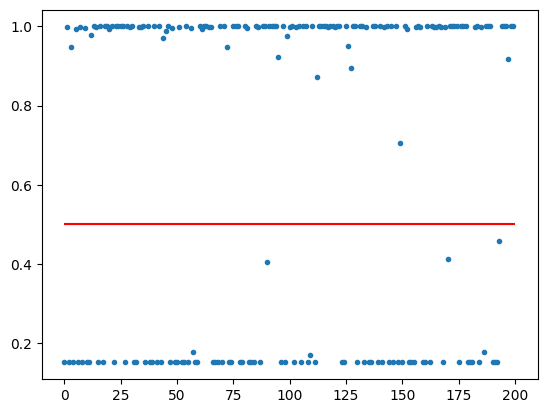

In [20]:
plt.scatter(
    x= range(len(binary_predictions_unlabeled)), 
    y = binary_predictions_unlabeled, 
    marker='.'
    )
plt.hlines(binary_cutoff_point, xmin=0, xmax=len(binary_predictions_unlabeled), color='red')

good - model seems to be able to pull stuff apart pretty well, however accuracy is on the low side 93% - will not futher pursue this route ; consider this notebook experimental. 

In [21]:

# Prepare angle labels
not_crappy_mask = labels != "crappy"
angle_labels = labels[not_crappy_mask]
angle_images = labeled_images[not_crappy_mask]


In [22]:

label_encoder = LabelEncoder()
angle_labels_encoded = label_encoder.fit_transform(angle_labels)


In [23]:

# Train angle classifier
X_train_angle, X_test_angle, y_train_angle, y_test_angle = train_test_split(angle_images, angle_labels_encoded, test_size=0.2, random_state=42)


In [24]:

angle_model.fit(X_train_angle, y_train_angle, epochs=10, batch_size=32, validation_split=0.2)


Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.2192 - loss: 1.9670 - val_accuracy: 0.4126 - val_loss: 1.2309
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.3885 - loss: 1.4710 - val_accuracy: 0.6808 - val_loss: 1.0324
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step - accuracy: 0.4370 - loss: 1.3584 - val_accuracy: 0.7080 - val_loss: 0.9328
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.4586 - loss: 1.3038 - val_accuracy: 0.7699 - val_loss: 0.8379
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.4474 - loss: 1.2703 - val_accuracy: 0.7929 - val_loss: 0.8134
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.4623 - loss: 1.2610 - val_accuracy: 0.8073 - val_loss: 0.7890
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - accuracy: 0.4775 - loss: 1.2118 - val_accuracy: 0.8107 - val_loss: 0.7550
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step - accuracy: 0.4917 - loss: 1

In [25]:

# Evaluate angle classifier
angle_loss, angle_accuracy = angle_model.evaluate(X_test_angle, y_test_angle)
print(f"Angle Classifier - Loss: {angle_loss}, Accuracy: {angle_accuracy}")


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8331 - loss: 0.7607
Angle Classifier - Loss: 0.7431380152702332, Accuracy: 0.8472505211830139


In [26]:
#visualize a confusion matrix: 
y_test_predictions = angle_model.predict(X_test_angle)
y_test_prediction_labels = np.argmax(y_test_predictions, axis=1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


In [27]:
labels_decoded = label_encoder.inverse_transform(range(8))
labels_decoded

array(['front', 'frontleft', 'frontright', 'left', 'rear', 'rearleft',
       'rearright', 'right'], dtype=object)

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'front'),
  Text(0, 1, 'frontleft'),
  Text(0, 2, 'frontright'),
  Text(0, 3, 'left'),
  Text(0, 4, 'rear'),
  Text(0, 5, 'rearleft'),
  Text(0, 6, 'rearright'),
  Text(0, 7, 'right')])

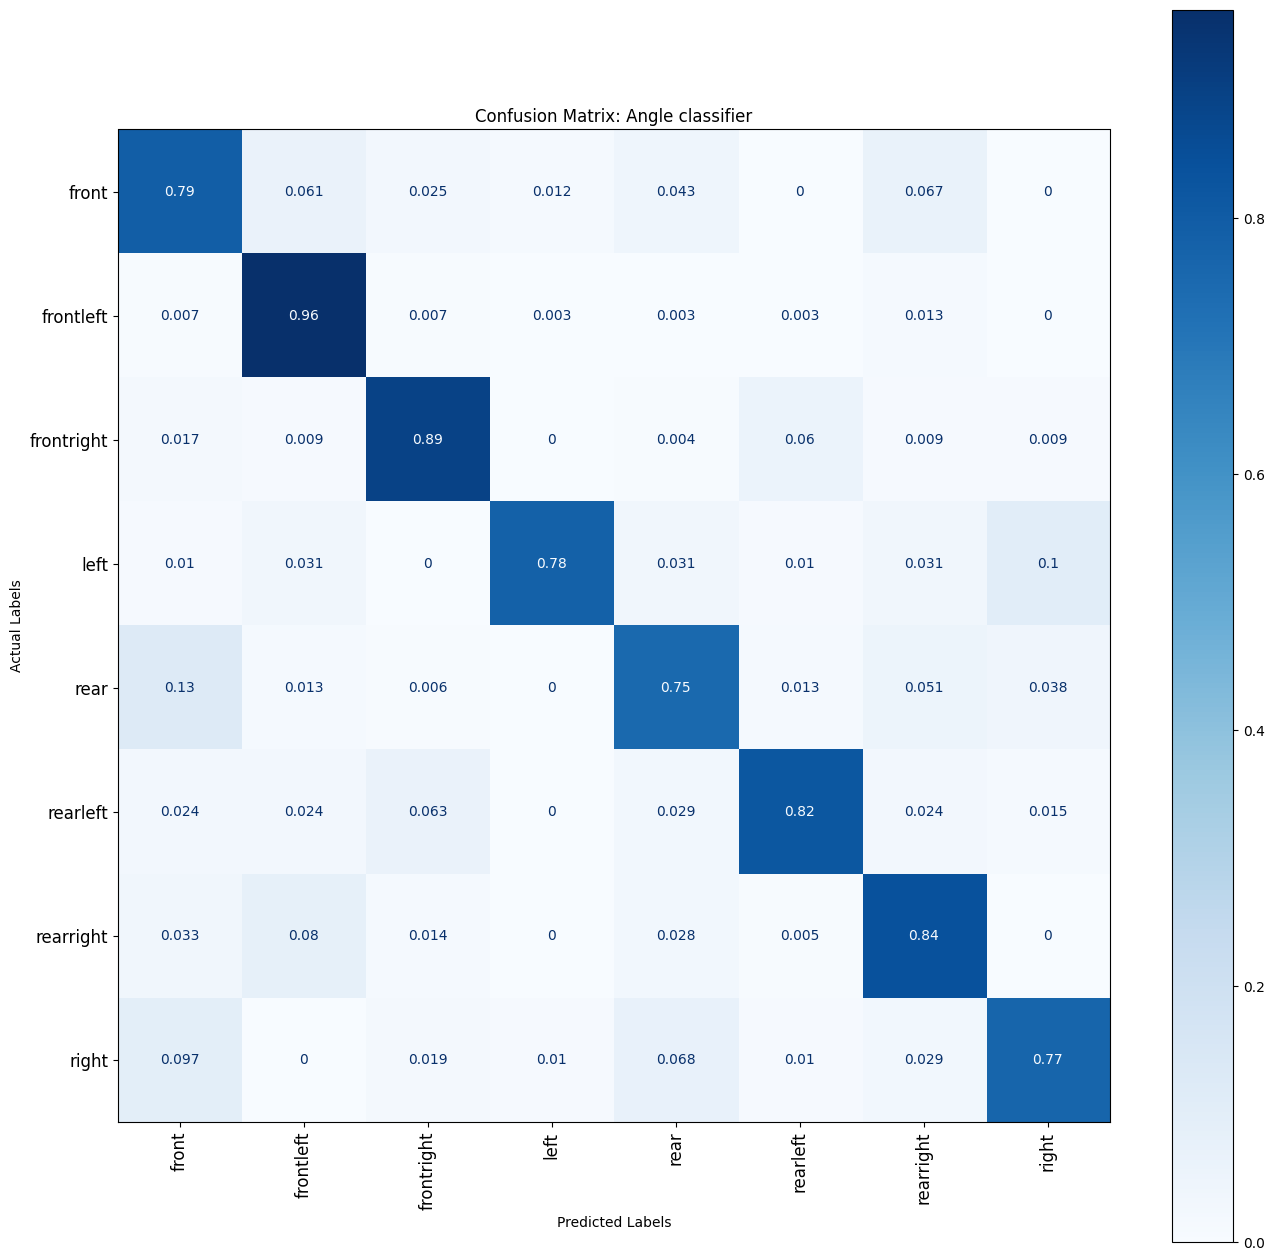

In [38]:
confusion_on_y_test = pd.DataFrame(
    {
        'actuals': y_test_angle,
        'predicts': y_test_prediction_labels
    }
)

#confusion_on_y_test.sample(5)
cm = implot.make_cm(confusion_on_y_test['actuals'], confusion_on_y_test['predicts'], labels_decoded)
cm.title("Confusion Matrix: Angle classifier")
cm.xticks(fontsize=12)
cm.yticks(fontsize=12)

In [39]:

# Predict angles for non-crappy images
predicted_angles = angle_model.predict(non_crappy_images)
predicted_labels = label_encoder.inverse_transform(np.argmax(predicted_angles, axis=1))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [40]:

random_unlabled_data = unlabeled_data.sample(200)
random_unlabled_data["predicted_label"] = "crappy"
random_unlabled_data.iloc[non_crappy_indices, random_unlabled_data.columns.get_loc("predicted_label")] = predicted_labels


In [41]:
random_unlabled_data.sample(10)

,yolobox_top_left_x,yolobox_top_left_y,yolobox_bottom_right_x,yolobox_bottom_right_y,abs_image_path,predicted_label
3677682,-1,-1,-1,-1,/home/frederic/Documents/automotive_image_data...,rearright
2124624,-1,-1,-1,-1,/home/frederic/Documents/automotive_image_data...,crappy
12032884,-1,-1,-1,-1,/home/frederic/Documents/automotive_image_data...,rear
10099454,30,0,750,538,/home/frederic/Documents/automotive_image_data...,frontleft
12116463,-1,-1,-1,-1,/home/frederic/Documents/automotive_image_data...,crappy
4326449,-1,-1,-1,-1,/home/frederic/Documents/automotive_image_data...,frontright
8239147,-1,-1,-1,-1,/home/frederic/Documents/automotive_image_data...,front
4578077,54,219,686,447,/home/frederic/Documents/automotive_image_data...,rearright
9189075,2,126,747,439,/home/frederic/Documents/automotive_image_data...,crappy
2489657,-1,-1,-1,-1,/home/frederic/Documents/automotive_image_data...,crappy
